Stichtag : 01.04.2020  | preis= 61  | ziad= 6216 | yolo= 7560


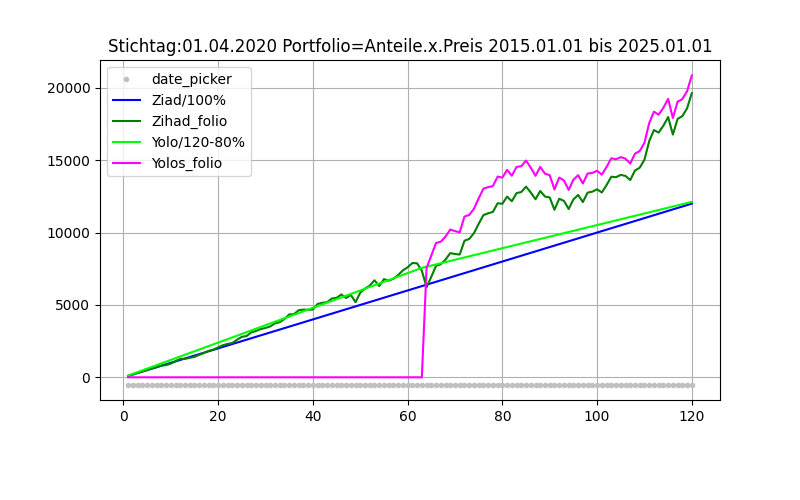

In [2]:
#16ziad-yolo_df.index.py 21.11.2025/28.1.25
#------------------------------------------
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox
import datetime
%matplotlib widget
# Load ETF data
df = yf.Ticker("VWRL.SW")
df = df.history(start="2015-01-01", end="2025-01-01")[["Close"]].copy()
df.index = df.index.tz_localize(None)
df.rename(columns={"Close": "Price"}, inplace=True)
df_monthly = df.resample("MS").first()

#print(df_monthly)
entry_date = '01.04.2020'   #--yolo
# possible invest-threshold
yolo_rate = 0 # vor den Stichtag anspar_rate dann danach_rate 
anspar_rate = 120
danach_rate = 80
konstant_rate = 100
#investment_per_month = spar_konstante
diagr_einh = 100
preis_linie = []
yoloanteilplan = []
trend_linie = []
yoloinvest = []
ziadinvest = []
yolo_folio = []#--yolo---
ziadanteilplan = []
trend_linie = []
ziad_folio = []
zeit_linie = []
pick1linie = []
pick1= -0.5
pick2linie = []
pick2= -500
raten_nr = 0
trend = 0
invest_flag = 0
invest_rate = 0
ziadanteilsum = 0
ziadfolio = 0
ziadsumme = 0
yoloanteilsum = 0#--yolo
yolofolio = 0    
yolosumme = 0
yolo_rate = anspar_rate
# -----------------------------BeginOfDataLoop-----------------------------------------    
for date, row in df_monthly.iterrows():
    #-------------------------   
    datum = date.strftime("%d.%m.%Y")
    if datum == entry_date:
       invest_flag = 1
       invest_rate = yolosumme
       yolo_rate = danach_rate
    #-------------------------   
    preis = row["Price"]
    yoloanteil= round(invest_rate / preis,2)
    ziadanteil= round(konstant_rate / preis,2)
    #-------------------------   
    if raten_nr > 1:
          trend = round((preis - altpreis)/diagr_einh,4)
          altpreis = preis
    else:
       altpreis = preis 
    raten_nr = raten_nr + 1
    ziadanteilsum = ziadanteilsum + ziadanteil
    ziadsumme = ziadsumme + konstant_rate
    ziadfolio = (ziadanteilsum)*preis
    yolosumme = yolosumme + yolo_rate
    #-------------------------
    if invest_flag ==1:
           invest_rate = danach_rate
           yoloanteilsum = yoloanteilsum + yoloanteil 
           yolofolio = (yoloanteilsum)*preis 
           yoloanteilplan.append(yoloanteil)
    else:
           invest_rate = 0
           yolofolio = 0
           yoloanteilplan.append(0)
    #-------------------------   
    preis_linie.append((round(preis/diagr_einh,2)))
    yoloinvest.append(round(yolosumme,2))
    ziadinvest.append(round(ziadsumme,2))
    ziadanteilplan.append(ziadanteil)
    trend_linie.append(trend)
    ziad_folio.append(ziadfolio)
    yolo_folio.append(yolofolio)
    zeit_linie.append(datum)
    pick1linie.append(pick1)
    pick2linie.append(pick2)
    if datum == entry_date:
       print('Stichtag :',entry_date,' | preis=',round(preis),' | ziad=',round(ziadfolio),'| yolo=',round(yolofolio))   
# -----------------------------EndOfDataLoop-------------------------------------------    
farbe = np.array(['silver','black','red','blue','green','lime','magenta','orange','teal','pink','navy','black'])
x1= np.linspace(1,len(pick1linie),len(pick1linie))
x2= np.linspace(1,len(pick2linie),len(pick2linie))
pri = preis_linie
yot = yoloanteilplan
yov = yoloinvest
ziv = ziadinvest
ant = ziadanteilplan
trd = trend_linie
zif = ziad_folio
yof = yolo_folio
pik1= pick1linie
pik2= pick2linie
#-----------------Monatswerte 1a -----------------
fig1 = plt.figure(figsize=(6, 5))
ax1 = fig1.add_subplot()
plt.subplots_adjust(bottom=0.2)
#2-Pixel-zeit-linie-picker Figur-1
line, = ax1.plot(x1,pik1, '.', picker=2,label='date_picker',color=farbe[0])
def on_pick(event):
     idx = int(event.ind[0])
     text = 'Dat:' + str(zeit_linie[idx]) +' Preis:'+ str(preis_linie[idx])
     text = text + ' trend:'+ str(trend_linie[idx])
     text = text + ' ziad-anteilkauf :'+ str(ziadanteilplan[idx])   
     textbox = TextBox(plt.axes([0.1, 0.05, 0.8, 0.1]),'',initial=text)     
     print(f't: {zeit_linie[idx]}')
     fig1.canvas.draw()
fig1.canvas.mpl_connect('pick_event', on_pick)
#-----------------MonatsWerte 1b -----------------
plt.plot(x1,pri, label='preis_linie',color=farbe[0],linestyle='solid')
plt.plot(x1,ant, label='ziadanteilkauf',color=farbe[1],linestyle='solid')
plt.plot(x1,trd, label='trend_linie',color=farbe[2],linestyle='solid')
plt.title("Ziads_plan start=2015-01-01 end=2025-01-01")
plt.grid(True)
plt.legend()
#-----------------MonatsBilanz 2a ----------------
fig2 = plt.figure(figsize=(8, 5))
ax2 = fig2.add_subplot()
plt.subplots_adjust(bottom=0.2)
#2-Pixel-zeit-linie-picker Figur-2
line, = ax2.plot(x2,pik2, '.', picker=2,label='date_picker',color=farbe[0])
def on_pick(event):
     idx = int(event.ind[0])
     text = 'Datum ' + str(zeit_linie[idx]) +'      Portfolios Ziad:'+ str(round(ziad_folio[idx]))
     text = text + '   Yolo:'+ str(round(yolo_folio[idx]))
     textbox = TextBox(plt.axes([0.1, 0.05, 0.8, 0.1]),'',initial=text)
     print(f't: {zeit_linie[idx]}')
     fig2.canvas.draw()
fig2.canvas.mpl_connect('pick_event', on_pick)
#-----------------MonatsBilanz 2b ----------------
text_ziad = 'Ziad/'+str(konstant_rate)+'%'
text_yolo = 'Yolo/'+str(anspar_rate)+'-'+str(danach_rate)+'%'
plt.plot(x2,ziv, label=text_ziad,color=farbe[3],linestyle='solid')
plt.plot(x2,zif, label='Zihad_folio',color=farbe[4],linestyle='solid')
plt.plot(x2,yov, label=text_yolo,color=farbe[5],linestyle='solid')
plt.plot(x2,yof, label='Yolos_folio',color=farbe[6],linestyle='solid')
text = 'Stichtag:'+ entry_date + ' Portfolio=Anteile.x.Preis 2015.01.01 bis 2025.01.01'
plt.title(text)
plt.grid(True)
plt.legend()
plt.show()





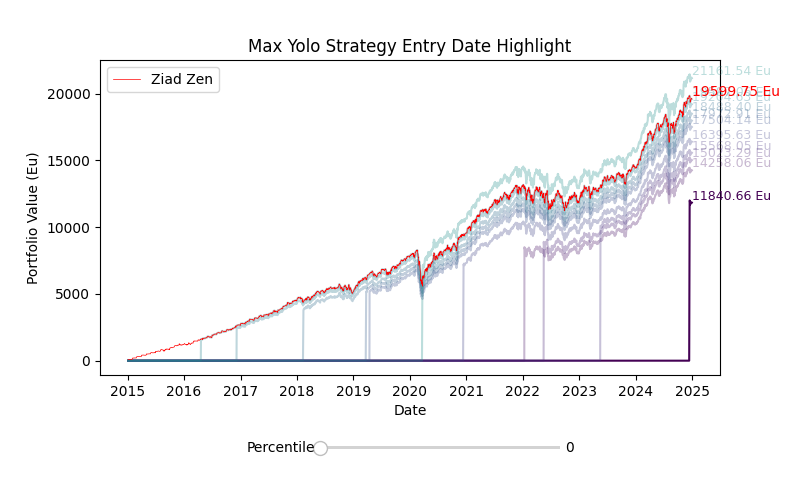

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib widget
# ---------------- PARAMETERS ----------------

START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
ETF = "VWRL.SW"
investment_per_month = 100

# ---------------- LOAD DATA ----------------

df = yf.Ticker(ETF).history(start=START_DATE, end=END_DATE)[["Close"]]
df.index = df.index.tz_localize(None)
df.rename(columns={"Close": "Price"}, inplace=True)
df_monthly = df.resample("MS").first()

entry_dates = df.index
end_date = df.index[-1]

# ---------------- STEP 1: FINAL VALUES ----------------

# TODO Task 1: Implement the "saved_amount" function to calculate 
# the total amount of monthly saved amount up to the given entry_date. 
def saved_amount(df_monthly, entry_date, investment_per_month):
    month_count = 0
    for month in df_monthly.index:
        if month < entry_date:
            month_count += 1
    saved_amount = month_count * investment_per_month
    return saved_amount

# TODO Task 2: Implement the "units_after_entry" function to calculate 
# the total number of units bought after the given entry_date, based 
# on "investment_per_month", the fixed monthly investment.
def units_after_entry(df_monthly, entry_date, investment_per_month):
    units_after_entry = 0.0
    for month in df_monthly.index:
        if month > entry_date:
            price = df_monthly.loc[month, "Price"]
            units_bought = investment_per_month / price
            units_after_entry += units_bought
    return units_after_entry

final_values = {}
for entry_date in entry_dates:
    entry_price = df.loc[entry_date, "Price"]   
    entry_units = saved_amount(df_monthly, entry_date, investment_per_month) / entry_price
    additional_units = units_after_entry(df_monthly, entry_date, investment_per_month)
    final_value = (entry_units + additional_units) * df.loc[end_date, "Price"]
    final_values[entry_date] = final_value

# ---------------- STEP 2: PERCENTILES ----------------

final_series = pd.Series(final_values).sort_values(ascending=True)
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
selected_entries = {}
N = len(final_series)

# TODO Task 3: For each percentile in the list, find the corresponding entry date 
# from the sorted "final_series" list. Store the result in "selected_entries" 
# as a mapping from percentile (key) to entry date (value). Recall that 
# the last index in final_series is (N-1).
for p in percentiles:
    idx = int(p / 100 * (N - 1))
    selected_entries[p] = final_series.index[idx]

# ---------------- ZIAD ZEN'S ENTRY DAY ----------------

first_day = df.index[0]
selected_entries['ziad_zen'] = first_day

# ---------------- STEP 3: PORTFOLIO PATHS ----------------

# TODO Task 4: Implement the "units_after_entry_before_date" function to calculate 
# the total number of units bought after the given entry_date and before the given date,
# based on "investment_per_month", the fixed monthly investment.
def units_after_entry_before_date(df_monthly, entry_date, date, investment_per_month):
    units_after_entry = 0.0 
    for month in df_monthly.index:
        if (month > entry_date) & (month <= date):
            price = df_monthly.loc[month, "Price"]
            units_bought = investment_per_month / price
            units_after_entry += units_bought
    return units_after_entry

portfolio_paths = {}
for key, entry_date in selected_entries.items():
    entry_price = df.loc[entry_date, "Price"]
    entry_units = saved_amount(df_monthly, entry_date, investment_per_month) / entry_price
    units_over_time = []
    for date in df.index:
        if date < entry_date:
            current_units = 0
        elif date == entry_date:
            current_units = entry_units
        else:
            current_units = entry_units
            current_units += units_after_entry_before_date(df_monthly, entry_date, date, investment_per_month)
        units_over_time.append(current_units * df.loc[date, "Price"])
    portfolio_paths[key] = pd.Series(units_over_time, index=df.index)

# ---------------- STEP 4: INTERACTIVE PLOT ----------------

fig, ax = plt.subplots(figsize=(8, 5))
plt.subplots_adjust(bottom=0.25)

# Colormap for MAX YOLO percentiles
colors = plt.cm.viridis(np.linspace(0, 0.5, len(percentiles)))
lines = {}
text_labels = {}

# MAX YOLO percentile paths
for i, p in enumerate(percentiles):
    series = portfolio_paths[p]
    line, = ax.plot(series.index, series.values,
                    color=colors[i], linestyle='-', alpha=0.3)
    lines[p] = line
    text = ax.text(series.index[-1], series.values[-1],
                   f"{series.values[-1]:.2f} Eu",
                   color=colors[i], alpha=0.3,
                   va='bottom', ha='left', fontsize=9)
    text_labels[p] = text

# Highlight initial (best)
current_p = percentiles[0]
lines[current_p].set_alpha(1.0)
text_labels[current_p].set_alpha(1.0)

# TODO Task 5: Plot the 'Ziad Zen' portfolio series in red, annotate the last value,
# and set appropriate plot title, axis labels, and legend.
zen_series = portfolio_paths['ziad_zen']
ax.plot(zen_series.index, zen_series.values,
                      color='red', linestyle='-', linewidth=0.5,
                      label='Ziad Zen', alpha=1)
ax.text(zen_series.index[-1], zen_series.values[-1],
        f"{zen_series.values[-1]:.2f} Eu", color='red',
        va='bottom', ha='left', fontsize=10)

ax.set_title("Max Yolo Strategy Entry Date Highlight")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (Eu)")
ax.legend()

# Slider
ax_slider = plt.axes([0.4, 0.1, 0.3, 0.01])
slider = Slider(ax_slider, "Percentile", 0, len(percentiles)-1, valinit=0, valstep=1)

def update(val):
    idx = int(slider.val)
    p_new = percentiles[idx]
    # TODO Task 6: Dim all lines and text labels for all percentiles to 0.3 alpha,
    # then highlight the currently selected percentile (p_new) by setting its line
    # and text label alpha to 1.0. This updates the plot appearance interactively.
    # Hint: Have a look at lines 130 and 131 above.
    for p in percentiles:
        lines[p].set_alpha(0.3)
        text_labels[p].set_alpha(0.3)
    lines[p_new].set_alpha(1.0)
    text_labels[p_new].set_alpha(1.0)
    ax.set_title(f"Max Yolo Eu {p_new}% Scenario Eu Entry Date: {selected_entries[p_new].date()}")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

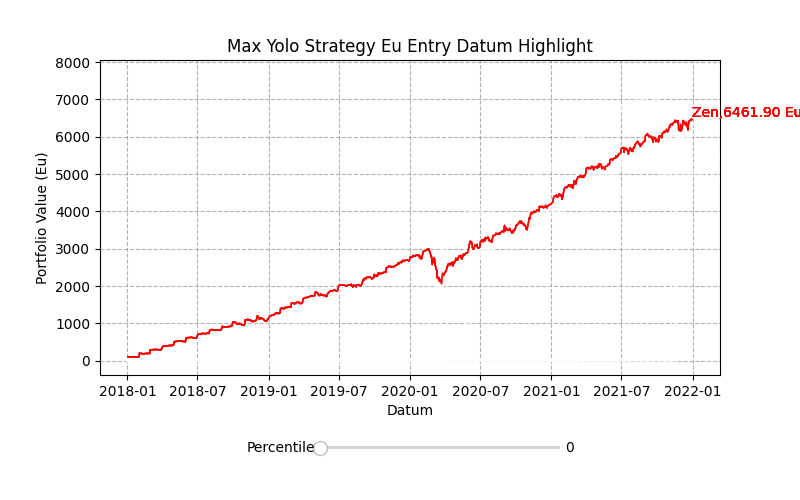

In [8]:
#loe_07
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib widget
# ---------------- PARAMETERS ----------------

START_DATUM = "2018-01-01"
END_DATUM = "2022-01-01"
VWRLSW = "VWRL.SW"
invest_pro_monat = 100

# ---------------- LOAD DATA ----------------

kurs = yf.Ticker(VWRLSW).history(start=START_DATUM, end=END_DATUM)[["Close"]]
kurs.index = kurs.index.tz_localize(None)
kurs.rename(columns={"Close": "Price"}, inplace=True)
monatl_kurs = kurs.resample("MS").first()

kurs_termine = kurs.index
END_DATUM = kurs.index[-1]

# ---------------- STEP 1: FINAL VALUES ----------------

# TODO Task 1: Implement the "spar_summe" function to calculate 
# the total amount of monthly saved amount up to the given invest_beginn. 
def spar_summe(monatl_kurs, invest_beginn, invest_pro_monat):
    monat_nr = 0
    for monat in monatl_kurs.index:
        if monat < invest_beginn:
            monat_nr += 1
    spar_summe = monat_nr * invest_pro_monat
    return spar_summe

# TODO Task 2: Implement the "anzahl_seit_beginn" function to calculate 
# the total number of units bought after the given invest_beginn, based 
# on "invest_pro_monat", the fixed monthly investment.
def einh_seit_beginn(monatl_kurs, invest_beginn, invest_pro_monat):
    einh_seitbeginn = 0.0 
    for monat in monatl_kurs.index:
        if monat > invest_beginn:
            preis = monatl_kurs.loc[monat, "Price"]
            einh_zahl = invest_pro_monat / preis
            einh_seitbeginn += einh_zahl
    return einh_seitbeginn

end_ergebnisse = {} 
for invest_beginn in kurs_termine:
    eingangs_preis = kurs.loc[invest_beginn, "Price"]   
    eingangs_einh = spar_summe(monatl_kurs, invest_beginn, invest_pro_monat) / eingangs_preis
    zusatz_einh  = einh_seit_beginn(monatl_kurs, invest_beginn, invest_pro_monat)
    end_ergebnis = (eingangs_einh + zusatz_einh) * kurs.loc[END_DATUM, "Price"]
    end_ergebnisse[invest_beginn] = end_ergebnis

# ---------------- STEP 2: PERCENTILES ----------------

ergebnis_aufsteigend = pd.Series(end_ergebnisse).sort_values(ascending=True)
percentiles = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
invest_start = {}
Nfs = len(ergebnis_aufsteigend)

# TODO Task 3: For each percentile in the list, find the corresponding entry Datum 
# from the sorted "ergebnis_aufsteigend" list. Store the result in "invest_start" 
# as a mapping from percentile (key) to entry Datum (value). Recall that 
# the last index in ergebnis_aufsteigend is (Nfs-1).
for p in percentiles:
    idx = int(p / 100 * (Nfs - 1))
    invest_start[p] = ergebnis_aufsteigend.index[idx]

# ---------------- ZIAD ZEN'S ENTRY DAY ----------------

kurs_beginn = kurs.index[0]
invest_start['ziad_zen'] = kurs_beginn

# ---------------- STEP 3: PORTFOLIO PATHS ----------------

# TODO Task 4: Implement the "zahl_nach_beginn_vor_datum" function to calculate 
# the total number of units bought after the given invest_beginn and before the given Datum,
# based on "invest_pro_monat", the fixed monthly investment.
def zahl_nach_beginn_vor_datum(monatl_kurs, invest_beginn, datum, invest_pro_monat):
    zahl_seit_beginn = 0.0 
    for monat in monatl_kurs.index:
        if (monat > invest_beginn) & (monat <= datum):
            preis = monatl_kurs.loc[monat, "Price"]
            einh_anzahl = invest_pro_monat / preis
            zahl_seit_beginn += einh_anzahl
    return zahl_seit_beginn

portfolio_paths = {}
for key, invest_beginn in invest_start.items():
    anfangs_preis = kurs.loc[invest_beginn, "Price"]
    anfangs_einh = spar_summe(monatl_kurs, invest_beginn, invest_pro_monat) / anfangs_preis
    units_over_time = []
    for datum in kurs.index:
        if datum < invest_beginn:
            current_units = 0
        elif datum == invest_beginn:
            current_units = anfangs_einh
        else:
            current_units = anfangs_einh
            current_units += zahl_nach_beginn_vor_datum(monatl_kurs, invest_beginn, datum, invest_pro_monat)
        units_over_time.append(current_units * kurs.loc[datum, "Price"])   
    portfolio_paths[key] = pd.Series(units_over_time, index=kurs.index)

# ---------------- STEP 4: INTERACTIVE PLOT ----------------
fig, ax = plt.subplots(figsize=(8, 5))
plt.subplots_adjust(bottom=0.25)
farbe = np.array(['white','silver','black','red','blue','green','lime','magenta','orange','teal','pink','navy','black'])

# TODO Task 5: Plot the 'Ziad Zen' portfolio as Reference with
# MAX YOLO percentile paths as Overlay-Verlaufs-Lines in a function

def percentil_verlauf(p,a,f,w):
    # YOLO
    series = portfolio_paths[p]
    line, = ax.plot(series.index, series.values,
                    color=farbe[f], linestyle='-',linewidth=w , alpha=a) 
    text = ax.text(series.index[-1], series.values[-1],
                   f"Yolo,{series.values[-1]:.2f} Eu",
                   color=farbe[f], alpha=a,
                   va='bottom', ha='left', fontsize=9)
    # ZEN
    zen_series = portfolio_paths['ziad_zen']
    ax.plot(zen_series.index, zen_series.values,
                       color='red', linestyle='-', linewidth=1.0,alpha=1)
    ax.text(zen_series.index[-1], zen_series.values[-1],
                       f"Zen,{zen_series.values[-1]:.2f} Eu", color=farbe[3],
                       va='bottom', ha='left', fontsize=10)
    ax.grid(True, linestyle='--', color='gray', alpha=0.6)

# Show Reference-Picture
for p in percentiles:
    percentil_verlauf(p,0.5,0,2)

ax.set_title("Max Yolo Strategy Eu Entry Datum Highlight")
ax.set_xlabel("Datum")
ax.set_ylabel("Portfolio Value (Eu)")
# ax.legend()
ax.grid(True, linestyle='--', color='gray', alpha=0.6)
# Slider
ax_slider = plt.axes([0.4, 0.1, 0.3, 0.01])
slider = Slider(ax_slider, "Percentile", 0, len(percentiles)-1, valinit=0, valstep=1)

def update(val):
    idx = int(slider.val)
    p_new = percentiles[idx]
    # TODO Task 6: set all Verlauf-lines in silver and Actual-slider-Verlauf in blue
    for p in percentiles:
        percentil_verlauf(p,1,0,2)
    percentil_verlauf(p_new,1,4,1)
    ax.set_title(f"Max Yolo{p_new}% Scenario Entry Datum: {invest_start[p_new].date()}")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()
